In [30]:
#Install required libraries for graph embeddings, visualization, and dashboard
!pip install -q streamlit
!pip install node2vec
!pip install pykeen pandas

In [31]:
#Import the primary libraries for data handling, graph construction, graph embeddings, and cosine similarity
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
from node2vec import Node2Vec
from pykeen.pipeline import pipeline
from pykeen.predict import predict_target
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import drive

In [32]:
#Mount the Google Drive and create a pathway to access the data
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Dataset.xlsx'
df = pd.read_excel(file_path, sheet_name='BINS_ONLY')

#Standardize column names for graph construction
triples_df = pd.DataFrame(df, columns=["SUBJECT", "PREDICATE", "OBJECT"])
triples_df = triples_df.rename(columns={"SUBJECT": "head", "PREDICATE": "relation", "OBJECT": "tail"})
print(triples_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
       head                      relation          tail
0      META                      ACQUIRES      MANUS AI
1  MANUS AI                          IS_A  APPLICATIONS
2  MANUS AI           DEAL_VALUE_CATEGORY         LARGE
3  MANUS AI        AMOUNT_RAISED_CATEGORY         LARGE
4  MANUS AI  NUMBER_OF_EMPLOYEES_CATEGORY         LARGE


In [33]:
#Core firms in dataset
firms = ['GOOGLE', 'APPLE', 'META', 'AMAZON', 'MICROSOFT']

#AI capability categories
categories = ["APPLICATIONS", "MODELING", "DATA", "COMPUTE"]

#Size bins
bins = ["SMALL", "MEDIUM", "LARGE"]

In [34]:
#Convert triples into PyKEEN format for knowledge graph modeling

from pykeen.triples import TriplesFactory

triples_df = triples_df.astype(str)

triples = triples_df.values

#Create TriplesFactory for TransE training
tf = TriplesFactory.from_labeled_triples(triples)

In [35]:
#Train TransE model on knowledge graph triples using PyKEEN

#Split dataset into train, test, and validation
training_set, testing_set, validation_set = tf.split([0.8, 0.1, 0.1])

#Run TransE training pipeline
result = pipeline(
    training=training_set,
    testing=testing_set,
    validation=validation_set,
    model='TransE',
    model_kwargs=dict(embedding_dim=50),
    optimizer_kwargs=dict(lr=0.01),
    training_kwargs=dict(num_epochs=100),
    random_seed=42)

INFO:pykeen.triples.splitting:done splitting triples to groups of sizes [253, 43, 43]
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/2.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/2.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/2.00 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/2.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/2.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/2.00 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/43.0 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.11s seconds


In [36]:
#Predict most likely tail entities with a given head and relation

predictions_df = predict_target(
    model=result.model,
    head='META',
    relation='ACQUIRES',
    triples_factory=training_set)

#Show top predictions for companies Meta acquires
predictions_df.df.head(20)

,tail_id,score,tail_label
77,77,-5.350196,SONICS
72,72,-6.045986,RIVOS
46,46,-6.727155,LIMITLESS
85,85,-6.795049,WAVEFORMS AI
14,14,-6.888875,ATLAS ML
75,75,-7.034482,SHOPAGON
68,68,-7.034942,PRESIZE.AI
6,6,-7.102912,AI.REVERIE
83,83,-7.397449,VOYSIS
15,15,-7.399096,AUDIO ANALYTIC


In [37]:
#Compare TransE embeddings using cosine similarity

for firm in firms:
    predictions_categories = ["APPLICATIONS", "MODELING", "DATA", "COMPUTE"]

    print(f"Cosine similarity scores for {firm}:")

    for cat in predictions_categories:
        #Get entity IDs required for embedding lookup
        head_id = result.training.entity_to_id[firm]
        tail_id = result.training.entity_to_id[cat]

        #Extract the embeddings from the model for cosine similarity
        head_emb = result.model.entity_representations[0](torch.tensor([head_id]))
        tail_emb = result.model.entity_representations[0](torch.tensor([tail_id]))

        #Compute cosine similarity scores
        score = cosine_similarity(head_emb.detach().numpy(), tail_emb.detach().numpy())[0][0]
        print(f"{cat}: {score:.4f}")

    print()

Cosine similarity scores for GOOGLE:
APPLICATIONS: 0.0927
MODELING: -0.1182
DATA: 0.0840
COMPUTE: -0.0416

Cosine similarity scores for APPLE:
APPLICATIONS: -0.0677
MODELING: -0.0471
DATA: -0.0458
COMPUTE: 0.2077

Cosine similarity scores for META:
APPLICATIONS: 0.1280
MODELING: 0.0650
DATA: -0.0379
COMPUTE: 0.1828

Cosine similarity scores for AMAZON:
APPLICATIONS: -0.0606
MODELING: -0.0901
DATA: 0.1220
COMPUTE: -0.2013

Cosine similarity scores for MICROSOFT:
APPLICATIONS: -0.2150
MODELING: -0.1715
DATA: 0.0176
COMPUTE: 0.1945



In [38]:
#Initialize an undirected graph and add edges
graph = nx.Graph()

for _, row in triples_df.iterrows():
    graph.add_edge(row["head"], row["tail"])

#Train the node2vec model on the graph structure and fit the model
node2vec = Node2Vec(graph, dimensions=64, walk_length=30, num_walks=200)
model = node2vec.fit(window=10, min_count=1)

#Store the embeddings in a dictionary for quick lookup
embeddings = {node: model.wv[node] for node in graph.nodes()}

Computing transition probabilities:   0%|          | 0/92 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:03<00:00, 61.94it/s]


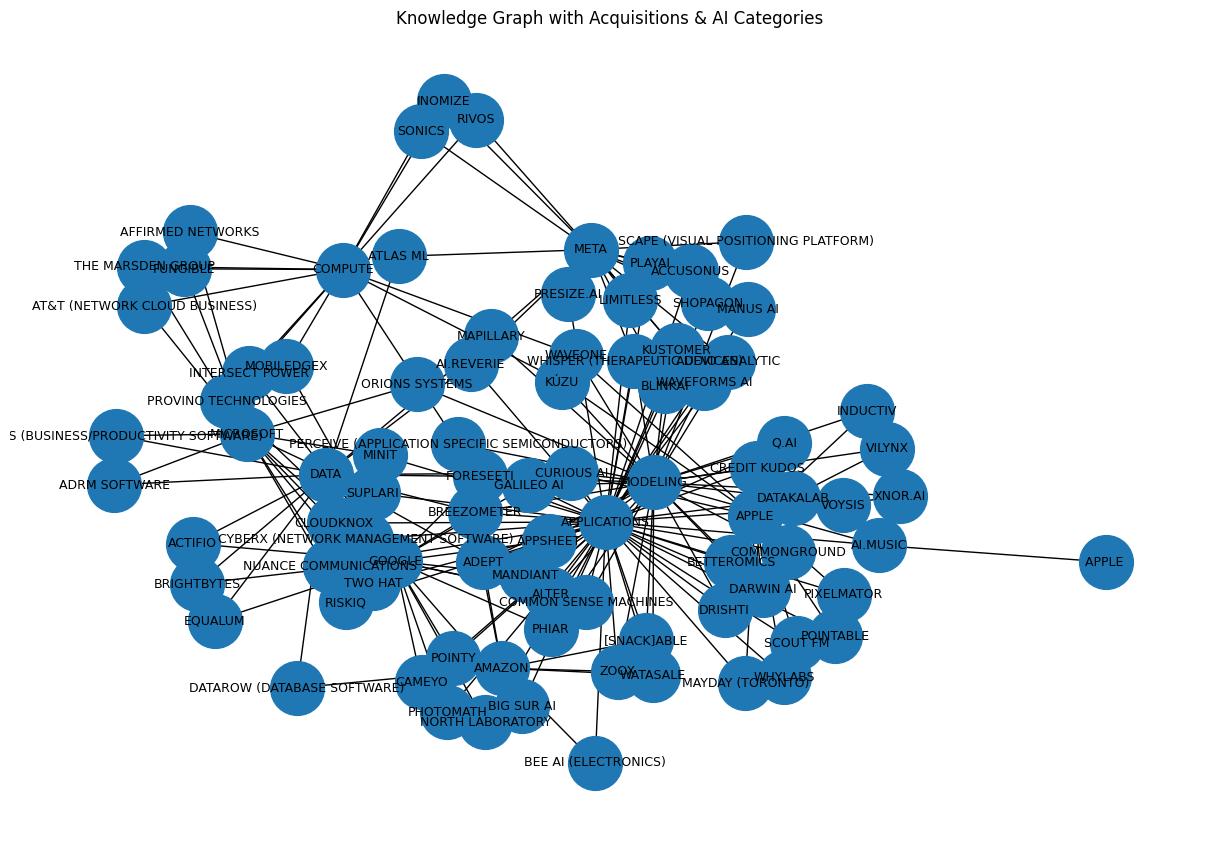

In [39]:
#Create an empty NetworkX graph
G = nx.Graph()

#Loop through each row in the dataframe and only keep acquisition and category relationships for the graph
for _, row in triples_df.iterrows():
    h = row["head"]
    t = row["tail"]
    r = row["relation"]
    if r == "ACQUIRES" or r == "IS_A":
        G.add_edge(h, t, relation=r)

#Set up the plot size and generate positions for nodes
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

#Draw the graph
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1500,
    font_size=9)

plt.title("Knowledge Graph with Acquisitions & AI Categories")
plt.axis("off")
plt.show()

In [40]:
#Build a filtered knowledge for visualization based on relation types.
#Parameters:
# - show_employees: toggle employee-related nodes
# - show_deals: toggle deal value categories
# - show_raised: toggle funding categories

def build_graph(triples_df, show_employees, show_deals, show_raised):
  graph_for_dashboard = nx.Graph()

  for x, row in triples_df.iterrows():
    h = row["head"]
    t = row["tail"]
    r = row["relation"]

    if r == "DEAL_VALUE_CATEGORY" and not show_deal_value:
      continue
    elif r == "AMOUNT_RAISED_CATEGORY" and not show_amount_raised:
      continue
    elif r == "NUMBER_OF_EMPLOYEES_CATEGORY" and not show_number_of_employees:
      continue

    graph_for_dashboard.add_edge(h, t, relation=r)

  return graph_for_dashboard

In [41]:
print("Cosine Similarity: Firms vs AI Categories\n")

#Compare each firm embedding to each AI category embedding
for firm in firms:
    print(f"{firm}:")

    for cat in categories:
      score = cosine_similarity([model.wv[firm]], [model.wv[cat]])[0][0]
      print(f"  {cat}: {score}")

print("\nCosine Similarity: Firms vs Size Bins\n")

#Compare firms against size classification embeddings
for firm in firms:
    print(f"{firm}:")

    for b in bins:
      score = cosine_similarity([model.wv[firm]], [model.wv[b]])[0][0]
      print(f"  {b}: {score}")

Cosine Similarity: Firms vs AI Categories

GOOGLE:
  APPLICATIONS: 0.3493228256702423
  MODELING: 0.24782505631446838
  DATA: 0.2947402000427246
  COMPUTE: 0.18621760606765747
APPLE:
  APPLICATIONS: 0.331255704164505
  MODELING: 0.3494790494441986
  DATA: 0.0570308119058609
  COMPUTE: 0.13443100452423096
META:
  APPLICATIONS: 0.3280671238899231
  MODELING: 0.2125139832496643
  DATA: 0.15875038504600525
  COMPUTE: 0.1866384744644165
AMAZON:
  APPLICATIONS: 0.24975250661373138
  MODELING: 0.2963380217552185
  DATA: 0.18631836771965027
  COMPUTE: 0.14663568139076233
MICROSOFT:
  APPLICATIONS: 0.31120264530181885
  MODELING: 0.06167779862880707
  DATA: 0.154426708817482
  COMPUTE: 0.34601354598999023

Cosine Similarity: Firms vs Size Bins

GOOGLE:
  SMALL: 0.2172420620918274
  MEDIUM: 0.27836039662361145
  LARGE: 0.287125825881958
APPLE:
  SMALL: 0.38852807879447937
  MEDIUM: 0.27256327867507935
  LARGE: 0.17095741629600525
META:
  SMALL: 0.27589431405067444
  MEDIUM: 0.29375505447387695
 

In [42]:
%%writefile app.py

#Import packages for the Streamlit dashboard
import streamlit as st
import pandas as pd
import networkx as nx
from node2vec import Node2Vec
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

#Load the dataset inside the dashboard
file_path = '/content/drive/MyDrive/Dataset.xlsx'
df = pd.read_excel(file_path, sheet_name = 'BINS_ONLY')

#Core firms in dataset
firms = ['GOOGLE', 'APPLE', 'META', 'AMAZON', 'MICROSOFT']

#AI capability categories
categories = ["APPLICATIONS", "MODELING", "DATA", "COMPUTE"]

#Size bins by deal
deal_bins = ["DEAL_SMALL", "DEAL_MEDIUM", "DEAL_LARGE"]

#Size bins by amount raised
amount_raised_bins = ["AMT_SMALL", "AMT_MEDIUM", "AMT_LARGE"]

#Size bins by number of employees
number_of_employees_bins = ["EMP_SMALL", "EMP_MEDIUM", "EMP_LARGE"]

#Standardize the columns for the knowledge graph
triples_df = pd.DataFrame(df, columns=["SUBJECT", "PREDICATE", "OBJECT"])
triples_df = triples_df.rename(columns={"SUBJECT": "head", "PREDICATE": "relation", "OBJECT": "tail"})
triples_df = triples_df.astype(str)

#Name bin nodes to ensure distinct embeddings across relation types
def name_bins(row):
    if row["relation"] == "DEAL_VALUE_CATEGORY":
        return f"DEAL_{row['tail']}"
    elif row["relation"] == "AMOUNT_RAISED_CATEGORY":
        return f"AMT_{row['tail']}"
    elif row["relation"] == "NUMBER_OF_EMPLOYEES_CATEGORY":
        return f"EMP_{row['tail']}"
    return row["tail"]

triples_df["tail"] = triples_df.apply(name_bins, axis=1)

#Initialize the graph and add it's edges in the dashboard
graph = nx.Graph()
for _, row in triples_df.iterrows():
    graph.add_edge(row["head"], row["tail"])

#Train the node2vec model in the dashboard
node2vec = Node2Vec(graph, dimensions=64, walk_length=30, num_walks=200)
model = node2vec.fit(window=10, min_count=1)

#Builds a graph based on a selected company and its acquisitions.
def build_graph(triples_df, selected_company, show_ai_category, show_deal_value, show_amount_raised, show_number_of_employees):
  graph_for_dashboard = nx.Graph()
  acquired_companies = set()

  #Identify acquired companies
  for x, row in triples_df.iterrows():
    if row["head"] == selected_company and row["relation"] == "ACQUIRES":
        acquired_companies.add(row["tail"])
        graph_for_dashboard.add_edge(row["head"], row["tail"], relation="ACQUIRES")

  #Add related information for acquired companies
  for y, row in triples_df.iterrows():
    h = row["head"]
    t = row["tail"]
    r = row["relation"]

    if r == "IS_A" and show_ai_category:
      if h in acquired_companies:
        graph_for_dashboard.add_edge(h, t, relation=r)

    if r == "DEAL_VALUE_CATEGORY" and show_deal_value:
      if h in acquired_companies:
        graph_for_dashboard.add_edge(h, t, relation=r)

    if r == "AMOUNT_RAISED_CATEGORY" and show_amount_raised:
      if h in acquired_companies:
        graph_for_dashboard.add_edge(h, t, relation=r)

    if r == "NUMBER_OF_EMPLOYEES_CATEGORY" and show_number_of_employees:
      if h in acquired_companies:
        graph_for_dashboard.add_edge(h, t, relation=r)

  return graph_for_dashboard

#Similarity matrices comparing GAFAM firms across different categorical variables
#Includes deal size, amount raised, number of employees, and AI capability category for acquired companies

#GAFAM firm similarity scores for AI capability categories (DATA, COMPUTE, MODELING, APPLICATIONS)
cat_matrix_display = []
for firm in firms:
  row = {"Firm": firm}
  for cat in categories:
    num = cosine_similarity([model.wv[firm]], [model.wv[cat]])[0][0]
    row[cat] = num
  cat_matrix_display.append(row)

cat_matrix_df = pd.DataFrame(cat_matrix_display)

#GAFAM firm similarity scores for deal value category bins
deal_bin_matrix = []

for firm in firms:
  row = {"Firm": firm}
  for b in deal_bins:
   num = cosine_similarity([model.wv[firm]], [model.wv[b]])[0][0]
   row[b] = num
  deal_bin_matrix.append(row)

deal_matrix_df = pd.DataFrame(deal_bin_matrix)

#GAFAM firm similarity scores for funding amount category bins
amount_raised_bin_matrix = []

for firm in firms:
  row = {"Firm": firm}
  for b in amount_raised_bins:
   num = cosine_similarity([model.wv[firm]], [model.wv[b]])[0][0]
   row[b] = num
  amount_raised_bin_matrix.append(row)

amount_raised_matrix_df = pd.DataFrame(amount_raised_bin_matrix)

#GAFAM firm similarity scores for employee count category bins
employee_bin_matrix = []

for firm in firms:
  row = {"Firm": firm}
  for b in number_of_employees_bins:
   num = cosine_similarity([model.wv[firm]], [model.wv[b]])[0][0]
   row[b] = num
  employee_bin_matrix.append(row)

employee_matrix_df = pd.DataFrame(employee_bin_matrix)

#Main Dashboard Navigation, users switch between different analytical views
st.title("Mapping AI Industry Structure Through Mergers and Acquisitions")
view = st.radio("Select View", ["Acquisitions", "AI Technical Stack Data", "Bin Data", "Charts", "Graphs"])

#Display raw acquisition data in the dashboard

if view == "Acquisitions":
  # Select firm to analyze acquisitions
  st.subheader("Raw Acquisition Data Overview by AI Category")
  selected_firm = st.selectbox("Select Company", firms)
  acquisitions = []

  #Find acquisition relationships of the selected firm
  for x, row in triples_df.iterrows():
    if row["head"] == selected_firm and row["relation"] == "ACQUIRES":
      acquired = row["tail"]

      #Find AI category of acquired company
      for y, r in triples_df.iterrows():
        if r["head"] == acquired and r["relation"] == "IS_A":
          acquisitions.append({"Acquiring Company": selected_firm, "Acquired Company": acquired, "AI Category": r['tail']})

  acquired_df = pd.DataFrame(acquisitions)
  st.dataframe(acquired_df)

elif view == "AI Technical Stack Data":
  st.subheader("Firm and AI Category Similarity Scores")

  #Display the matrix for GAFAM firm similarity scores for AI capability categories (DATA, COMPUTE, MODELING, APPLICATIONS)
  st.dataframe(cat_matrix_df)

elif view == "Bin Data":
  st.subheader("Firm and Bin Similarity Scores")
  selected_firm = st.selectbox("Select Company", firms)

  #Filter similarity tables that have already been computed
  employee_scores = employee_matrix_df[employee_matrix_df["Firm"] == selected_firm]
  deal_scores = deal_matrix_df[deal_matrix_df["Firm"] == selected_firm]
  amount_raised_scores = amount_raised_matrix_df[amount_raised_matrix_df["Firm"] == selected_firm]

  #Display matrices
  st.write("Number of Employees Category")
  st.dataframe(employee_scores)

  st.write("Deal Value Category")
  st.dataframe(deal_scores)

  st.write("Amount Raised Category")
  st.dataframe(amount_raised_scores)

elif view == "Charts":
  st.subheader("Cosine Similarity of AI Acquisition Strategies by Company")
  firm = st.selectbox("Pick a firm", firms)

  #Compute similarity score to size bins
  deal_scores = {}
  for b in deal_bins:
    if b in model.wv and firm in model.wv:
      score = cosine_similarity([model.wv[firm]], [model.wv[b]])[0][0]
      deal_scores[b] = score

  amount_raised_scores = {}
  for b in amount_raised_bins:
    if b in model.wv and firm in model.wv:
      score = cosine_similarity([model.wv[firm]], [model.wv[b]])[0][0]
      amount_raised_scores[b] = score

  employee_count_scores = {}
  for b in number_of_employees_bins:
    if b in model.wv and firm in model.wv:
      score = cosine_similarity([model.wv[firm]], [model.wv[b]])[0][0]
      employee_count_scores[b] = score

  #Compute similarity score to AI categories
  cat_scores = {}
  for c in categories:
    if c in model.wv:
      score = cosine_similarity([model.wv[firm]], [model.wv[c]])[0][0]
      cat_scores[c] = score

  #Convert from dictionaries to dataframes for plotting
  deal_bin_df = pd.DataFrame({"Category": list(deal_scores.keys()), "Similarity": list(deal_scores.values())})
  amount_raised_bin_df = pd.DataFrame({"Category": list(amount_raised_scores.keys()), "Similarity": list(amount_raised_scores.values())})
  employee_count_bin_df = pd.DataFrame({"Category": list(employee_count_scores.keys()), "Similarity": list(employee_count_scores.values())})
  cat_df = pd.DataFrame({"Category": list(cat_scores.keys()), "Similarity": list(cat_scores.values())})

  #Display two side by side charts
  row1_col1, row1_col2 = st.columns(2)
  row2_col1, row2_col2 = st.columns(2)

  with row1_col1:
    st.subheader("AI Capability Categories")
    st.bar_chart(cat_df, x="Category", y="Similarity")

  with row1_col2:
    st.subheader("Deal Size Categories")
    st.bar_chart(deal_bin_df, x="Category", y="Similarity")

  with row2_col1:
    st.subheader("Amount Raised Categories")
    st.bar_chart(amount_raised_bin_df, x="Category", y="Similarity")

  with row2_col2:
    st.subheader("Employee Size Categories")
    st.bar_chart(employee_count_bin_df, x="Category", y="Similarity")

elif view == "Graphs":
  st.subheader("Company-Level Knowledge Graphs")

  selected_company = st.selectbox("Pick a firm", firms)

  #Toggle filters for graph visualization
  show_ai_category = st.checkbox("AI Category", True)
  show_employees = st.checkbox("Employee Categories", True)
  show_deals = st.checkbox("Deal Value Categories", True)
  show_raised = st.checkbox("Amount Raised Categories", True)

  #Build filtered graph
  G = build_graph(triples_df, selected_company, show_ai_category, show_deals, show_raised, show_employees)

  #Draw graph
  fig, ax = plt.subplots(figsize=(10, 8))
  pos = nx.spring_layout(G, seed=42)

  nx.draw_networkx_nodes(G, pos, ax=ax)
  nx.draw_networkx_edges(G, pos, alpha=0.4, ax=ax)
  nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

  ax.set_axis_off()
  st.pyplot(fig)

Overwriting app.py


In [43]:
#Kill any Streamlit or Cloudflare processes from previous runs
!pkill -f cloudflared; pkill -f streamlit; sleep 2

#Launch Streamlit app on port 8502
!python -m streamlit run app.py \
  --server.port 8502 \
  --server.address 0.0.0.0 \
  --server.fileWatcherType none \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  &> logs.txt &

import time, subprocess, re
time.sleep(5)

#Download Cloudflare tunnel to create a public URL for the locally running Streamlit app
import subprocess
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

#Run Cloudflare and save its output to a file
cloudflared_log = open("cloudflared_log.txt", "w")
proc = subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://localhost:8502"], stdout=cloudflared_log, stderr=cloudflared_log)

#Wait for Cloudflare to generate a public URL
url = None
for _ in range(30):
    time.sleep(1)
    try:
        with open("cloudflared_log.txt", "r") as f:
            content = f.read()
        match = re.search(r"https://[\w-]+\.trycloudflare\.com", content)
        if match:
            url = match.group(0)
            break
    except:
        pass

print("Open this URL:", url)

^C
Open this URL: https://kernel-frog-forge-lifestyle.trycloudflare.com
